In [1]:
import os
os.environ["TFHUB_CACHE_DIR"] = r"C:\Users\xpetr\tfhub_cache"   # add before hub.load()
import numpy as np
import pandas as pd
# import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, hamming_loss, f1_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import tensorflow_datasets as tfds
import pandas as pd
import shutil, os
cache_dir = os.path.join(os.getcwd(), "vec_cache")
shutil.rmtree(cache_dir, ignore_errors=True)

c:\Users\587978\.conda\envs\epu\Lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [2]:
version = 6
TARGET_PER_LABEL = 4000

train_ratio = 0.5
val_ratio   = 0.25
test_ratio  = 0.25


In [3]:
EMOTION_LABELS = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval',
    'caring', 'confusion', 'curiosity', 'desire', 'disappointment',
    'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear',
    'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism',
    'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise',
    'neutral'
]

ds_train, ds_val, ds_test = tfds.load('goemotions', split=['train', 'validation', 'test'])

def split_to_rows(dataset):
    rows = []
    for ex in dataset.as_numpy_iterator():
        text = ex['comment_text'].decode('utf-8')
        bools = [bool(ex[label]) for label in EMOTION_LABELS]
        rows.append([text] + bools)
    return rows

all_rows = []
for split in [ds_train, ds_val, ds_test]:
    all_rows.extend(split_to_rows(split))

final_df = pd.DataFrame(all_rows, columns=['text'] + EMOTION_LABELS)


In [4]:
final_df.to_csv("Goemotions_54262.csv")

## 1. Load data

In [5]:
final_df[EMOTION_LABELS] = final_df[EMOTION_LABELS].astype(int)   # bool -> 0/1

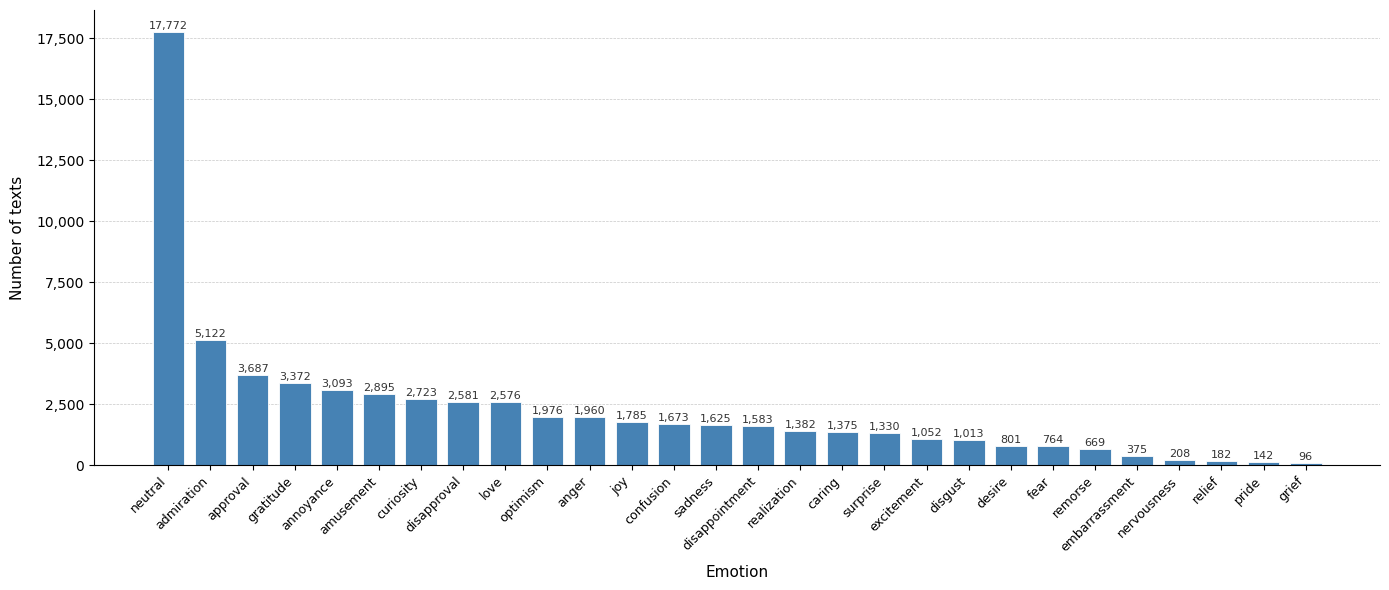

In [6]:
label_counts = final_df[EMOTION_LABELS].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(label_counts.index, label_counts.values,
              color='steelblue', edgecolor='white', linewidth=0.6, width=0.75)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 40,
            f'{int(h):,}', ha='center', va='bottom',
            fontsize=8, color='#333333')

ax.set_title('',
             fontsize=15, fontweight='bold', pad=16)
ax.set_xlabel('Emotion', fontsize=11, labelpad=8)
ax.set_ylabel('Number of texts', fontsize=11, labelpad=8)
ax.set_xticks(range(len(label_counts)))
ax.set_xticklabels(label_counts.index, rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('emotion_label_distribution.png', dpi=400, bbox_inches='tight')
plt.show()

In [7]:
KEEP_EVERY_N = 6   # keep every Nth neutral row (systematic thinning, no randomness)

neutral_rows     = final_df[final_df['neutral'] == 1]
non_neutral_rows = final_df[final_df['neutral'] == 0]

# Keep rows at positions 0, 10, 20, ... — deterministic, order-preserving
neutral_thinned = neutral_rows.iloc[::KEEP_EVERY_N]

df = pd.concat([non_neutral_rows, neutral_thinned], ignore_index=True)

print(f"After thinning  — total rows  : {len(df):,}")
print(f"Neutral rows    : {df['neutral'].sum():,}  ({len(neutral_thinned):,} kept of {len(neutral_rows):,}, every {KEEP_EVERY_N}th)")
print(f"Non-neutral rows: {(df['neutral'] == 0).sum():,}")
print(f"Neutral frequency : {df['neutral'].mean()*100:.1f}%")

After thinning  — total rows  : 39,453
Neutral rows    : 2,962  (2,962 kept of 17,772, every 6th)
Non-neutral rows: 36,491
Neutral frequency : 7.5%


## 2. Train / validation / test split

In [8]:
os.environ["TFHUB_CACHE_DIR"] = r"C:\Users\587978\Research\tfhub_cache"

USE_URL = "https://tfhub.dev/google/universal-sentence-encoder/4"

if "encoder" not in dir():
    print(f"Loading USE from {USE_URL} …")
    encoder = hub.load(USE_URL)
    print("Encoder loaded.")
EMBED_DIM = 512

if "encoder" not in dir():
    print(f"Loading USE from {USE_URL} …")
    encoder = hub.load(USE_URL)
    print("Encoder loaded.")

def batch_encode_use(texts, batch_size=512):
    parts = []
    for i in range(0, len(texts), batch_size):
        parts.append(encoder(texts[i : i + batch_size].tolist()).numpy())
    return np.vstack(parts).astype(np.float32)

Loading USE from https://tfhub.dev/google/universal-sentence-encoder/4 …



Encoder loaded.


In [9]:
# ── ISMOTE oversampling for minority emotion labels ───────────────────────────
from sklearn.neighbors import NearestNeighbors

def ismote_augment(X_vec, y_multi, target_per_label=600, k=5, random_state=42):
    rng = np.random.RandomState(random_state)
    X_syn_list, y_syn_list = [], []
    n_labels = y_multi.shape[1]

    for i in range(n_labels):
        pos_mask  = y_multi[:, i] == 1
        pos_count = int(pos_mask.sum())
        n_gen     = target_per_label - pos_count
        if n_gen <= 0 or pos_count < 2:
            continue

        X_pos    = X_vec[pos_mask]
        y_pos    = y_multi[pos_mask]
        k_actual = min(k, pos_count - 1)

        nn = NearestNeighbors(n_neighbors=k_actual + 1, n_jobs=-1).fit(X_pos)
        _, nbrs = nn.kneighbors(X_pos)
        nbrs = nbrs[:, 1:]

        for _ in range(n_gen):
            q       = rng.randint(pos_count)
            j       = nbrs[q, rng.randint(k_actual)]
            Xq, Xj  = X_pos[q], X_pos[j]
            diff    = Xq - Xj
            alpha   = rng.random()
            beta    = rng.random()
            Xnew1   = Xq + alpha * diff
            d_tot   = np.linalg.norm(diff)
            if d_tot == 0:
                X_syn_list.append(Xq.copy())
            else:
                d_n1 = np.linalg.norm(Xnew1 - Xq)
                Xnew = (Xnew1 - beta * diff) if d_n1 >= 0.5 * d_tot \
                       else (Xnew1 + beta * diff)
                X_syn_list.append(Xnew)
            y_syn_list.append(y_pos[q])

        print(f"  {EMOTION_LABELS[i]:<18}  {pos_count:>4} → {pos_count + n_gen:>4}  (+{n_gen})")

    if not X_syn_list:
        print("No augmentation needed — all labels already meet target.")
        return X_vec, y_multi

    X_syn = np.array(X_syn_list, dtype=np.float32)
    y_syn = np.array(y_syn_list, dtype=np.float32)
    return np.vstack([X_vec, X_syn]), np.vstack([y_multi, y_syn])


# ── 1. Encode the full dataset ────────────────────────────────────────────────
X_all = df['text'].values
y_all = df[EMOTION_LABELS].values.astype(np.float32)

CACHE_DIR  = os.path.join(os.getcwd(), "vec_cache")
CACHE_FILE = os.path.join(CACHE_DIR, "X_all_vec.npy")
os.makedirs(CACHE_DIR, exist_ok=True)

if os.path.exists(CACHE_FILE):
    print("Loading cached USE vectors …")
    X_all_vec = np.load(CACHE_FILE)
    print(f"  loaded {X_all_vec.shape}")
else:
    print("Encoding full dataset with USE (first run — will be cached) …")
    X_all_vec = batch_encode_use(X_all)
    np.save(CACHE_FILE, X_all_vec)
    print(f"  cached to {CACHE_FILE}  {X_all_vec.shape}")

n_original = len(X_all_vec)


# ── 2. ISMOTE on the full dataset ─────────────────────────────────────────────
print(f"\nApplying ISMOTE to full dataset ({n_original:,} samples) …")
print(f"  target = {TARGET_PER_LABEL} positives per label\n")

X_aug, y_aug = ismote_augment(X_all_vec, y_all, target_per_label=TARGET_PER_LABEL)

X_syn = X_aug[n_original:]
y_syn = y_aug[n_original:]

print(f"\nOriginal  : {n_original:,} samples")
print(f"Synthetic : {len(X_syn):,} samples")
print(f"Total     : {len(X_aug):,} samples")


# ── 3. Split originals into train / val / test ────────────────────────────────
X_orig = X_aug[:n_original]
y_orig = y_aug[:n_original]

# Step 1: carve out (val + test) as temp  →  train = train_ratio
X_tr, X_temp, y_tr, y_temp = train_test_split(
    X_orig, y_orig, test_size=(val_ratio + test_ratio), random_state=42
)
# Step 2: split temp into val and test using their relative proportions
X_val_vec, X_test_vec, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=(test_ratio / (val_ratio + test_ratio)), random_state=42
)

# All synthetics go to train only
X_train_aug = np.vstack([X_tr, X_syn])
y_train_aug = np.vstack([y_tr, y_syn])

total = len(X_tr) + len(X_val_vec) + len(X_test_vec)
print(f"\nTrain (orig + synthetic) : {len(X_train_aug):,}  "
      f"({len(X_tr):,} real + {len(X_syn):,} synthetic)  "
      f"[{100*len(X_tr)/total:.0f}% of originals]")
print(f"Val  (original only)     : {len(X_val_vec):,}  [{100*len(X_val_vec)/total:.0f}%]")
print(f"Test (original only)     : {len(X_test_vec):,}  [{100*len(X_test_vec)/total:.0f}%]")

pos_counts  = y_train_aug.sum(axis=0)
neg_counts  = len(y_train_aug) - pos_counts
pos_weights = (neg_counts / np.maximum(pos_counts, 1)).astype(np.float32)
print(f"\npos_weights after ISMOTE — min: {pos_weights.min():.1f}  "
      f"max: {pos_weights.max():.1f}")

Encoding full dataset with USE (first run — will be cached) …
  cached to c:\Users\587978\Research\data_prep\vec_cache\X_all_vec.npy  (39453, 512)

Applying ISMOTE to full dataset (39,453 samples) …
  target = 4000 positives per label

  amusement           2833 → 4000  (+1167)
  anger               1900 → 4000  (+2100)
  annoyance           2944 → 4000  (+1056)
  approval            3480 → 4000  (+520)
  caring              1306 → 4000  (+2694)
  confusion           1569 → 4000  (+2431)
  curiosity           2588 → 4000  (+1412)
  desire               775 → 4000  (+3225)
  disappointment      1516 → 4000  (+2484)
  disapproval         2473 → 4000  (+1527)
  disgust              986 → 4000  (+3014)
  embarrassment        360 → 4000  (+3640)
  excitement          1023 → 4000  (+2977)
  fear                 742 → 4000  (+3258)
  gratitude           3358 → 4000  (+642)
  grief                 93 → 4000  (+3907)
  joy                 1742 → 4000  (+2258)
  love                2542 → 4000  

In [10]:
# ── 4. Save splits ────────────────────────────────────────────────────────────
import json

OUT_DIR = rf"C:\Users\587978\Research\Unsloth_model\data_split\augmented{version}"
os.makedirs(OUT_DIR, exist_ok=True)

splits = {
    "train": (X_train_aug, y_train_aug),
    "val":   (X_val_vec,   y_val),
    "test":  (X_test_vec,  y_test),
}

for name, (X, y) in splits.items():
    path = os.path.join(OUT_DIR, f"{name}.json")
    with open(path, "w", encoding="utf-8") as f:
        json.dump({"X": X.tolist(), "y": y.tolist()}, f)
    print(f"Saved {path}  (X: {X.shape[0]} × {X.shape[1]},  y: {y.shape[0]} × {y.shape[1]})")

Saved C:\Users\587978\Research\Unsloth_model\data_split\augmented6\train.json  (X: 85256 × 512,  y: 85256 × 28)
Saved C:\Users\587978\Research\Unsloth_model\data_split\augmented6\val.json  (X: 9863 × 512,  y: 9863 × 28)
Saved C:\Users\587978\Research\Unsloth_model\data_split\augmented6\test.json  (X: 9864 × 512,  y: 9864 × 28)


In [11]:
# 3) EDA
splits = {
    'Train':      (X_train_aug, y_train_aug),
    'Validation': (X_val_vec,   y_val),
    'Test':       (X_test_vec,  y_test)
}
colors = ['steelblue', 'darkorange', 'seagreen']

# ── 1. Label counts & frequency table ─────────────────────────────────────
counts  = {name: pd.Series(y.sum(axis=0), index=EMOTION_LABELS) for name, (_, y) in splits.items()}
count_df = pd.DataFrame(counts)
freq_df  = pd.DataFrame({name: count_df[name] / len(y) * 100 for name, (_, y) in splits.items()})

print("=== Label counts per split ===")
print(count_df.to_string())
print("\n=== Label frequency (%) per split ===")
print(freq_df.round(2).to_string())

=== Label counts per split ===
                 Train  Validation    Test
admiration      5387.0      1249.0  1249.0
amusement       3651.0       727.0   671.0
anger           3929.0       497.0   466.0
annoyance       4459.0       733.0   748.0
approval        4128.0       832.0   903.0
caring          4315.0       355.0   306.0
confusion       3828.0       372.0   411.0
curiosity       4205.0       626.0   638.0
desire          4042.0       180.0   206.0
disappointment  4604.0       334.0   410.0
disapproval     3701.0       629.0   621.0
disgust         4100.0       249.0   218.0
embarrassment   4123.0        73.0   103.0
excitement      4099.0       278.0   247.0
fear            4705.0       174.0   206.0
gratitude       3841.0       880.0   804.0
grief           4092.0        24.0    27.0
joy             4512.0       449.0   390.0
love            3696.0       629.0   616.0
nervousness     4249.0        50.0    49.0
optimism        4857.0       455.0   477.0
pride           3975.0 

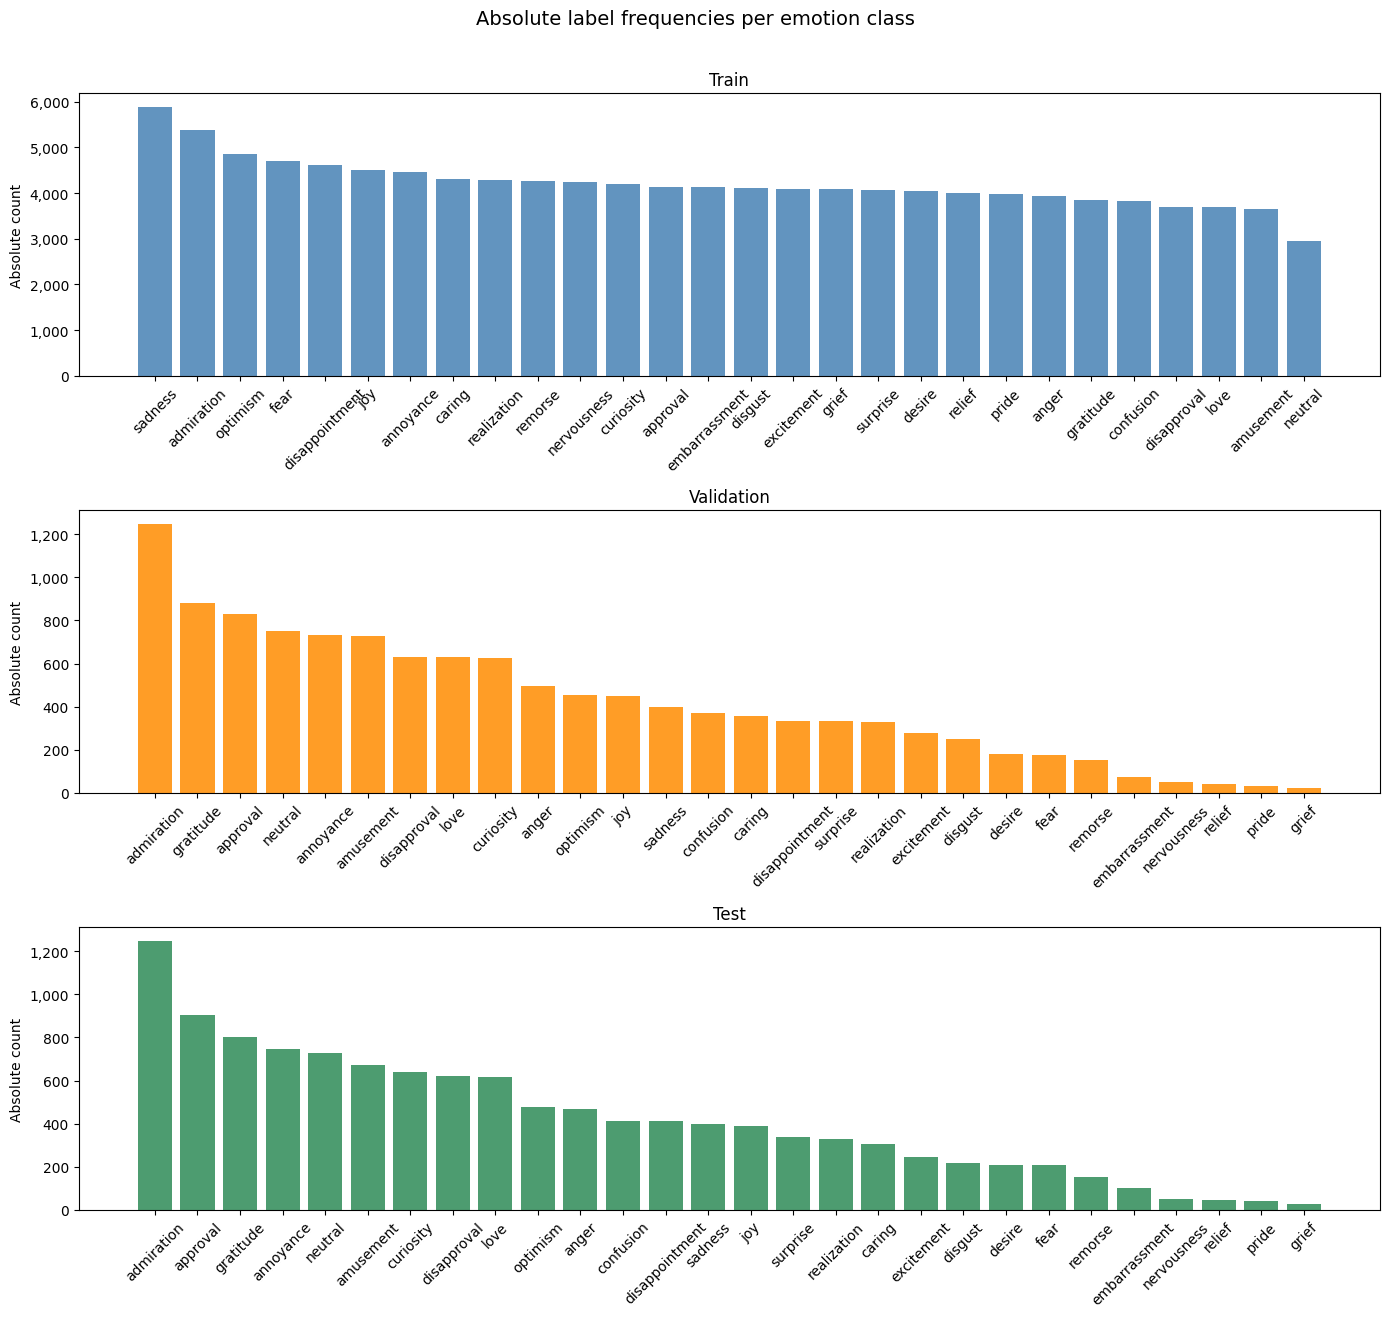

In [12]:
# ── Absolute label frequencies — 3 sorted bar subplots ────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharey=False)
for ax, (name, color) in zip(axes, zip(splits.keys(), colors)):
    sorted_series = count_df[name].sort_values(ascending=False)
    ax.bar(sorted_series.index, sorted_series.values, color=color, alpha=0.85)
    ax.set_title(f'{name}', fontsize=12)
    ax.set_ylabel('Absolute count')
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))

plt.suptitle('Absolute label frequencies per emotion class', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_label_freq_sorted_bars.png', dpi=150, bbox_inches='tight')
plt.show()

=== Label counts per split ===
                 Train  Validation    Test
admiration      5387.0      1249.0  1249.0
amusement       3651.0       727.0   671.0
anger           3929.0       497.0   466.0
annoyance       4459.0       733.0   748.0
approval        4128.0       832.0   903.0
caring          4315.0       355.0   306.0
confusion       3828.0       372.0   411.0
curiosity       4205.0       626.0   638.0
desire          4042.0       180.0   206.0
disappointment  4604.0       334.0   410.0
disapproval     3701.0       629.0   621.0
disgust         4100.0       249.0   218.0
embarrassment   4123.0        73.0   103.0
excitement      4099.0       278.0   247.0
fear            4705.0       174.0   206.0
gratitude       3841.0       880.0   804.0
grief           4092.0        24.0    27.0
joy             4512.0       449.0   390.0
love            3696.0       629.0   616.0
nervousness     4249.0        50.0    49.0
optimism        4857.0       455.0   477.0
pride           3975.0 

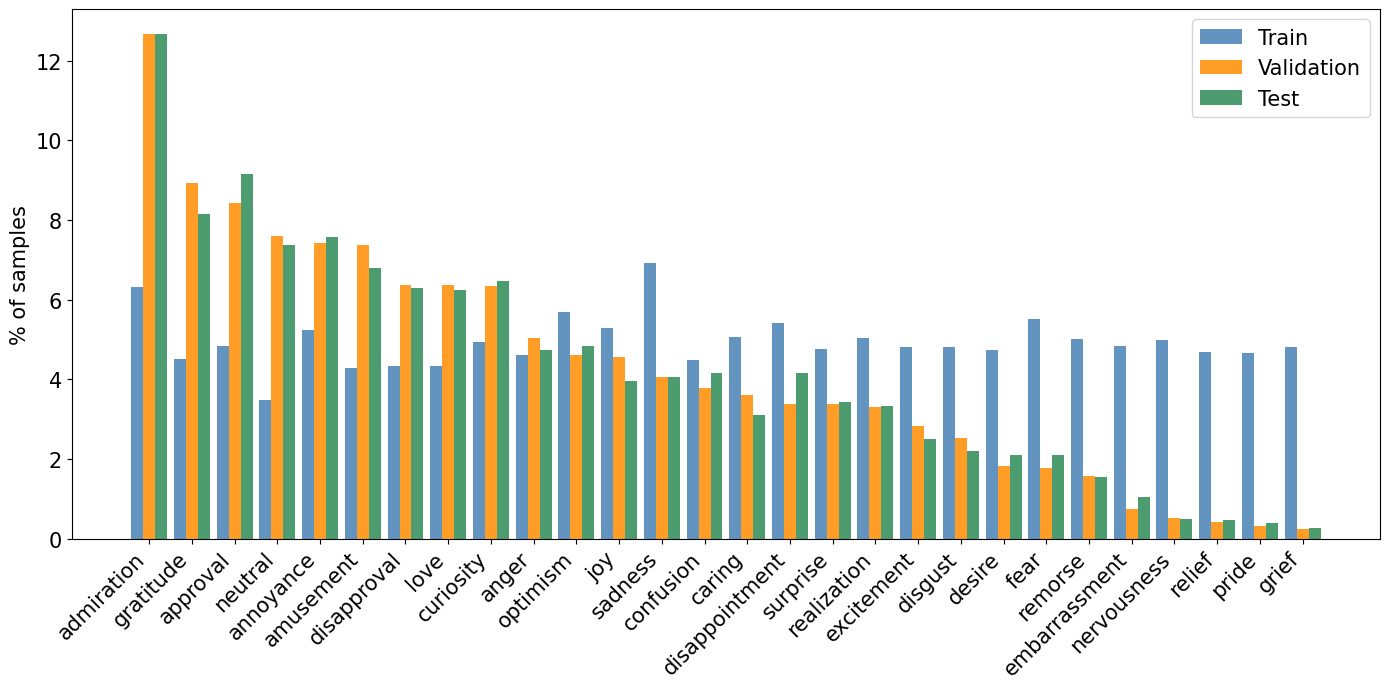

In [13]:
# ── 1. Label counts & frequency table ─────────────────────────────────────
counts  = {name: pd.Series(y.sum(axis=0), index=EMOTION_LABELS) for name, (_, y) in splits.items()}
count_df = pd.DataFrame(counts)
freq_df  = pd.DataFrame({name: count_df[name] / len(y) * 100 for name, (_, y) in splits.items()})

print("=== Label counts per split ===")
print(count_df.to_string())
print("\n=== Label frequency (%) per split ===")
print(freq_df.round(2).to_string())

# ── 2. Relative frequency — grouped bar, sorted by Validation desc ─────────
order = pd.Series(splits['Validation'][1].sum(axis=0) / len(splits['Validation'][1]) * 100,
                  index=EMOTION_LABELS).sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 7))
x     = np.arange(len(EMOTION_LABELS))
width = 0.28
for i, (name, color) in enumerate(zip(splits.keys(), colors)):
    _, y = splits[name]
    freq = pd.Series(y.sum(axis=0) / len(y) * 100, index=EMOTION_LABELS).reindex(order)
    ax.bar(x + i * width, freq.values, width, label=name, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(order, rotation=45, ha='right')
ax.set_ylabel('% of samples', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(fontsize=15)
plt.tight_layout()
plt.savefig('eda_relative_freq_all_sets.png', dpi=700, bbox_inches='tight')
plt.show()